# Gas Lift Allocation Optimization across a Well Group

**Goal:** allocate a fixed lift-gas supply across 8 wells to maximize total oil,
and quantify the value of optimization vs equal split.

**Technique highlights**
* GLPC fitting per well from noisy multi-rate test data
* **SLSQP constrained optimization** with the equal-slope optimality check
* Marginal-barrel curve: what is the next MMscf/d of compression worth?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Gas lift test data and GLPC model

GLPC model: q_oil(g) = q_max · (1 − exp(−g/g₁)) − c·g  (rise to plateau, then decline).

In [2]:
def glpc(g, q_max, g1, c):
    return q_max * (1 - np.exp(-g / g1)) - c * g

TRUE = {  # well: (q_max stb/d, g1 MMscf/d, c)
    f"GL-{i+1}": (q, g1, c) for i, (q, g1, c) in enumerate([
        (950, 0.9, 55), (620, 0.5, 70), (1400, 1.5, 60), (480, 0.35, 90),
        (1100, 1.1, 45), (760, 0.8, 80), (1650, 1.8, 50), (540, 0.6, 100)])
}

rows = []
for well, (q_max, g1, c) in TRUE.items():
    for g in np.linspace(0.1, 3.0, 8):
        rows.append({"well": well, "gas_mmscfd": round(g, 2),
                     "oil_stbd": round(max(glpc(g, q_max, g1, c)
                                           * rng.normal(1, 0.04), 0), 1)})
tests = pd.DataFrame(rows)
tests.to_csv("gas_lift_test_data.csv", index=False)

fits = {}
for well, g in tests.groupby("well"):
    p, _ = curve_fit(glpc, g.gas_mmscfd, g.oil_stbd, p0=[800, 1.0, 60],
                     bounds=([100, 0.1, 0], [3000, 5, 300]), maxfev=10_000)
    fits[well] = p
wells = list(fits)

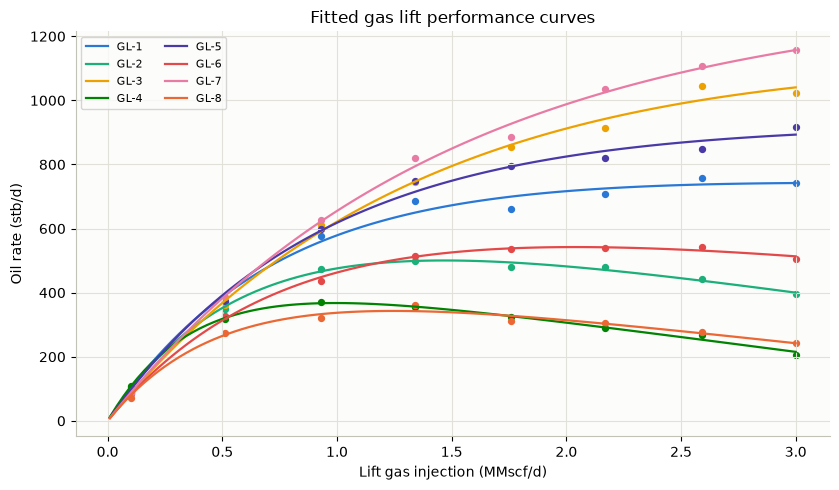

In [3]:
gg = np.linspace(0.01, 3, 100)
plt.figure(figsize=(8.5, 5))
for i, well in enumerate(wells):
    pts = tests[tests.well == well]
    plt.scatter(pts.gas_mmscfd, pts.oil_stbd, s=18, color=PALETTE[i % 8])
    plt.plot(gg, glpc(gg, *fits[well]), lw=1.6, color=PALETTE[i % 8], label=well)
plt.xlabel("Lift gas injection (MMscf/d)")
plt.ylabel("Oil rate (stb/d)")
plt.title("Fitted gas lift performance curves")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 2. Constrained allocation

In [4]:
G_TOTAL = 8.0  # MMscf/d available

def total_oil(alloc):
    return sum(glpc(g, *fits[w]) for g, w in zip(alloc, wells))

def optimize(g_total):
    x0 = np.full(len(wells), g_total / len(wells))
    res = minimize(lambda x: -total_oil(x), x0, method="SLSQP",
                   bounds=[(0, 3.0)] * len(wells),
                   constraints=[{"type": "eq", "fun": lambda x: x.sum() - g_total}])
    return res.x, -res.fun

alloc_opt, oil_opt = optimize(G_TOTAL)
alloc_eq = np.full(len(wells), G_TOTAL / len(wells))
oil_eq = total_oil(alloc_eq)
print(f"Equal split: {oil_eq:,.0f} stb/d   Optimized: {oil_opt:,.0f} stb/d   "
      f"gain = {oil_opt - oil_eq:,.0f} stb/d ({100 * (oil_opt / oil_eq - 1):.1f}%)")

# equal-slope optimality check
slopes = [(glpc(g + 1e-4, *fits[w]) - glpc(g, *fits[w])) / 1e-4
          for g, w in zip(alloc_opt, wells) if g > 1e-3]
print("Marginal slopes at optimum (should be ~equal):",
      np.round(slopes, 1))

Equal split: 4,117 stb/d   Optimized: 4,411 stb/d   gain = 294 stb/d (7.1%)
Marginal slopes at optimum (should be ~equal): [271.3 271.3 271.3 271.3 271.3 271.3 271.3 271.3]


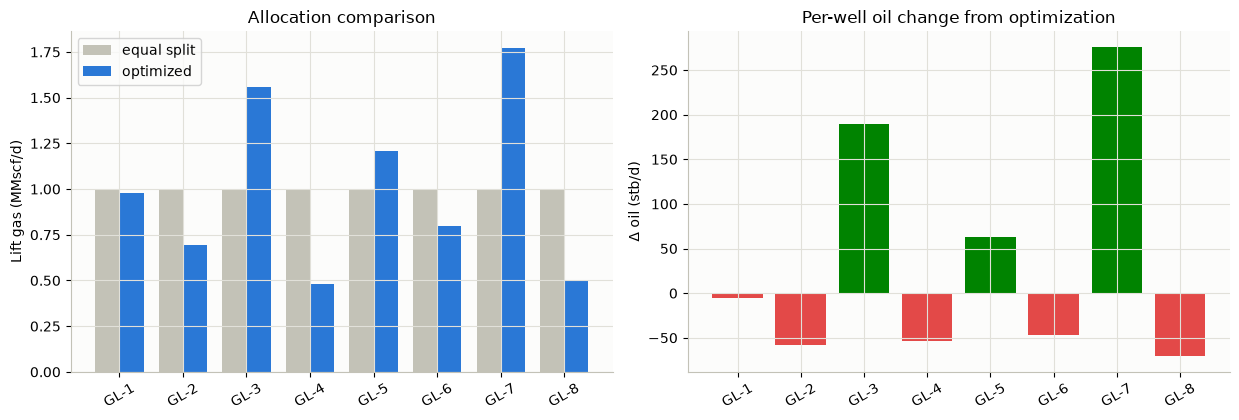

In [5]:
x = np.arange(len(wells))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
axes[0].bar(x - 0.19, alloc_eq, width=0.38, color="#c3c2b7", label="equal split")
axes[0].bar(x + 0.19, alloc_opt, width=0.38, color=PALETTE[0], label="optimized")
axes[0].set_xticks(x, wells, rotation=30)
axes[0].set(ylabel="Lift gas (MMscf/d)", title="Allocation comparison")
axes[0].legend()

oil_by_well_eq = [glpc(g, *fits[w]) for g, w in zip(alloc_eq, wells)]
oil_by_well_opt = [glpc(g, *fits[w]) for g, w in zip(alloc_opt, wells)]
axes[1].bar(x, np.array(oil_by_well_opt) - np.array(oil_by_well_eq),
            color=[PALETTE[3] if v >= 0 else PALETTE[5]
                   for v in np.array(oil_by_well_opt) - np.array(oil_by_well_eq)])
axes[1].set_xticks(x, wells, rotation=30)
axes[1].set(ylabel="Δ oil (stb/d)", title="Per-well oil change from optimization")
plt.tight_layout()
plt.show()

## 3. Marginal-barrel curve — pricing more compression

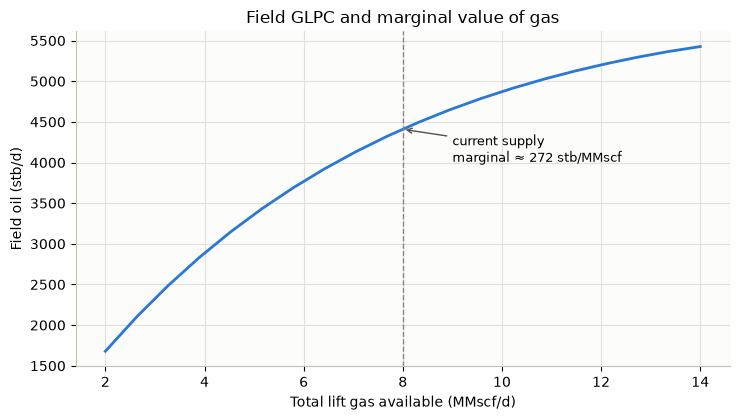

In [6]:
totals = np.linspace(2, 14, 20)
field_oil = [optimize(g)[1] for g in totals]
marginal = np.gradient(field_oil, totals)

fig, ax1 = plt.subplots(figsize=(7.5, 4.3))
ax1.plot(totals, field_oil, lw=2, color=PALETTE[0])
ax1.set(xlabel="Total lift gas available (MMscf/d)", ylabel="Field oil (stb/d)",
        title="Field GLPC and marginal value of gas")
ax2_vals = marginal
ax1.axvline(G_TOTAL, ls="--", lw=1, color="#898781")
ax1.annotate(f"current supply\nmarginal ≈ {np.interp(G_TOTAL, totals, marginal):,.0f} stb/MMscf",
             xy=(G_TOTAL, np.interp(G_TOTAL, totals, field_oil)),
             xytext=(G_TOTAL + 1, np.interp(G_TOTAL, totals, field_oil) - 400),
             fontsize=9, arrowprops=dict(arrowstyle="->", color="#52514e"))
plt.tight_layout()
plt.show()

## Conclusions

* Optimization adds meaningful oil over equal split by starving flat-curve wells and
  feeding gas-hungry ones; the equal-marginal-slope check confirms a true optimum.
* The marginal-barrel curve turns compressor debottlenecking into an economics
  question with a number attached: barrels per incremental MMscf/d **at the optimum
  allocation**, not at the status quo.
* The workflow is testable: GLPC fits come from routine multi-rate tests, so this runs
  with data most fields already collect.
* **Next step:** add per-well gas handling constraints and water handling coupling,
  and refresh GLPCs continuously from production data instead of discrete tests.